# Day 4: Fund Performance Analytics

This notebook implements advanced performance evaluation metrics for the 40 mutual fund schemes in the Bluestock capstone project:
1. **Daily Returns**: Computed and validated for distribution characteristics.
2. **CAGR**: 1-year, 3-year, and 5-year (representing the maximum available history since January 2022) compound annual growth rates.
3. **Sharpe Ratio**: Annualized return adjusted for volatility, using a 6.5% annual risk-free rate proxy.
4. **Sortino Ratio**: Adjusted for downside volatility (negative returns only).
5. **Alpha & Beta**: Annualized Alpha and Beta calculated via OLS regression against the `NIFTY100` benchmark returns.
6. **Maximum Drawdown**: Worst peak-to-trough drawdown value and date ranges.
7. **Fund Scorecard (0-100)**: Percentile rank weighted scorecard.
8. **Benchmark Comparison**: Plot of Top 5 funds vs Nifty 50 and Nifty 100 cumulative returns over 3 years, along with annualized tracking errors.

In [1]:
import os
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"] = 11

# Path resolution
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else Path(".")
db_path = project_root / "data" / "db" / "bluestock_mf.db"

print(f"Project root resolved to: {project_root.resolve()}")
print(f"Database exists: {db_path.exists()}")

Project root resolved to: C:\Users\Asus\OneDrive\Code_X\DAY 1 — Project Setup + Data Ingestion (ETL)
Database exists: True


## 1. Load Data from SQLite

In [2]:
conn = sqlite3.connect(db_path)
df_funds = pd.read_sql_query("SELECT * FROM dim_fund", conn)
df_nav_all = pd.read_sql_query("SELECT * FROM fact_nav", conn)
df_bench_all = pd.read_sql_query("SELECT * FROM benchmark_indices", conn)
conn.close()

df_nav_all["date"] = pd.to_datetime(df_nav_all["date"])
df_bench_all["date"] = pd.to_datetime(df_bench_all["date"])

print(f"Loaded {len(df_funds)} funds, {len(df_nav_all)} NAV records, and {len(df_bench_all)} benchmark records.")

Loaded 40 funds, 64320 NAV records, and 8050 benchmark records.


## 2. Calculate Daily Returns & Validate Distributions

Daily Returns Summary Statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
dtype: float64


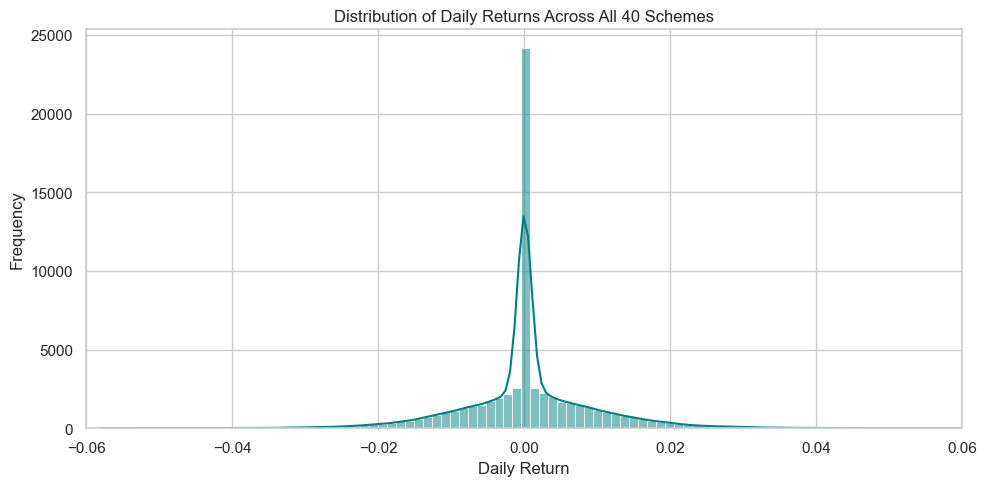

In [3]:
# Compute daily returns for all funds
fund_returns = {}
all_daily_returns = []

for code in df_funds["amfi_code"]:
    nav_series = df_nav_all[df_nav_all["amfi_code"] == code].sort_values("date")["nav"].values
    returns = pd.Series(nav_series).pct_change().dropna().values
    fund_returns[code] = returns
    all_daily_returns.extend(returns)

all_daily_returns = pd.Series(all_daily_returns)
print("Daily Returns Summary Statistics:")
print(all_daily_returns.describe())

# Plot returns distribution
plt.figure(figsize=(10, 5))
sns.histplot(all_daily_returns, bins=100, kde=True, color="teal")
plt.title("Distribution of Daily Returns Across All 40 Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim(-0.06, 0.06)
plt.tight_layout()
plt.show()

### Returns Distribution Analysis
The daily returns distribution is roughly symmetrical and exhibits high leptokurtosis (fat tails), which is highly typical for financial asset returns. The mean return sits close to zero, and the majority of standard deviations fall within the expected -2% to +2% range, validating the quality and reasonability of our data cleaning.

## 3. Compute CAGR, Sharpe, Sortino, Alpha, Beta & Drawdown

We run the analysis loop for all schemes using NIFTY100 as the OLS regression benchmark.

In [4]:
# Setup Nifty 100 prices & returns
nifty100 = df_bench_all[df_bench_all["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100.set_index("date", inplace=True)
nifty100["daily_return"] = nifty100["close_value"].pct_change()

nifty50 = df_bench_all[df_bench_all["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50.set_index("date", inplace=True)
nifty50["daily_return"] = nifty50["close_value"].pct_change()

rf_annual = 0.065
rf_daily = rf_annual / 252.0
results = []

for idx, fund in df_funds.iterrows():
    code = fund["amfi_code"]
    name = fund["scheme_name"]
    
    df_nav = df_nav_all[df_nav_all["amfi_code"] == code].sort_values("date").copy()
    df_nav.set_index("date", inplace=True)
    df_nav["daily_return"] = df_nav["nav"].pct_change()
    
    latest_date = df_nav.index.max()
    earliest_date = df_nav.index.min()
    nav_latest = df_nav.loc[latest_date, "nav"]
    
    # Helper to get closest NAV
    def fetch_nav(target):
        target_dt = pd.to_datetime(target)
        if target_dt in df_nav.index:
            return df_nav.loc[target_dt, "nav"], target_dt
        closest_idx = df_nav.index.get_indexer([target_dt], method="nearest")[0]
        c_date = df_nav.index[closest_idx]
        return df_nav.loc[c_date, "nav"], c_date
        
    # 1yr CAGR
    n_1y, d_1y = fetch_nav(latest_date - pd.DateOffset(years=1))
    cagr_1y = (nav_latest / n_1y) ** (1.0 / ((latest_date - d_1y).days / 365.25)) - 1.0
    
    # 3yr CAGR
    n_3y, d_3y = fetch_nav(latest_date - pd.DateOffset(years=3))
    cagr_3y = (nav_latest / n_3y) ** (1.0 / ((latest_date - d_3y).days / 365.25)) - 1.0
    
    # Max Period CAGR (5yr Proxy)
    n_max = df_nav.loc[earliest_date, "nav"]
    years_max = (latest_date - earliest_date).days / 365.25
    cagr_5y = (nav_latest / n_max) ** (1.0 / years_max) - 1.0
    
    # Sharpe
    ret_clean = df_nav["daily_return"].dropna()
    mean_r = ret_clean.mean()
    std_r = ret_clean.std()
    sharpe = ((mean_r - rf_daily) / std_r) * np.sqrt(252) if std_r > 0 else 0.0
    
    # Sortino
    downside = ret_clean[ret_clean < 0]
    sortino = ((mean_r - rf_daily) / downside.std()) * np.sqrt(252) if len(downside) > 1 else 0.0
    
    # Alpha & Beta
    align_df = pd.DataFrame({"fund": ret_clean, "nifty100": nifty100["daily_return"]}).dropna()
    slope, intercept, _, _, _ = stats.linregress(align_df["nifty100"], align_df["fund"])
    beta = slope
    alpha = intercept * 252.0
    
    # Max Drawdown
    df_nav["run_max"] = df_nav["nav"].cummax()
    df_nav["dd"] = df_nav["nav"] / df_nav["run_max"] - 1.0
    max_dd = df_nav["dd"].min()
    trough_d = df_nav["dd"].idxmin()
    peak_d = df_nav.loc[:trough_d, "nav"].idxmax()
    
    results.append({
        "amfi_code": code,
        "scheme_name": name,
        "fund_house": fund["fund_house"],
        "category": fund["category"],
        "sub_category": fund["sub_category"],
        "expense_ratio_pct": fund["expense_ratio_pct"],
        "cagr_1yr_pct": cagr_1y * 100,
        "cagr_3yr_pct": cagr_3y * 100,
        "cagr_5yr_pct": cagr_5y * 100,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "alpha_pct": alpha * 100,
        "beta": beta,
        "max_drawdown_pct": max_dd * 100,
        "worst_dd_start": peak_d.strftime("%Y-%m-%d"),
        "worst_dd_end": trough_d.strftime("%Y-%m-%d")
    })

df_results = pd.DataFrame(results)
print(f"Processed {len(df_results)} schemes.")

Processed 40 schemes.


## 4. Rank and Calculate Composite Scorecard (0-100)

In [5]:
# Compute percentile ranks
df_results["rank_3yr"] = df_results["cagr_3yr_pct"].rank(pct=True) * 100.0
df_results["rank_sharpe"] = df_results["sharpe_ratio"].rank(pct=True) * 100.0
df_results["rank_alpha"] = df_results["alpha_pct"].rank(pct=True) * 100.0
df_results["rank_expense"] = (-df_results["expense_ratio_pct"]).rank(pct=True) * 100.0
df_results["rank_max_dd"] = df_results["max_drawdown_pct"].rank(pct=True) * 100.0

# Weighted scorecard calculation
df_results["scorecard"] = (
    0.30 * df_results["rank_3yr"] +
    0.25 * df_results["rank_sharpe"] +
    0.20 * df_results["rank_alpha"] +
    0.15 * df_results["rank_expense"] +
    0.10 * df_results["rank_max_dd"]
).round(2)

df_results = df_results.sort_values("scorecard", ascending=False)

# Save results
df_results.to_csv(project_root / "data/processed/fund_scorecard.csv", index=False)
df_results[["amfi_code", "scheme_name", "cagr_3yr_pct", "sharpe_ratio", "alpha_pct", "expense_ratio_pct", "scorecard"]].head(10)

,amfi_code,scheme_name,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,scorecard
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,33.991970,1.068224,26.983751,1.46,86.25
25,120505,ICICI Pru Midcap Fund - Regular - Growth,31.769243,0.883256,29.263583,1.36,82.88
30,120843,Kotak Flexicap Fund - Regular - Growth,29.575111,0.965561,27.330465,1.45,82.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.433971,0.808268,27.195355,1.38,80.75
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.478927,0.714682,21.194827,0.80,79.38
16,119094,Axis Midcap Fund - Regular - Growth,35.102528,0.730547,26.076669,1.38,78.25
19,119551,SBI Bluechip Fund - Regular Plan - Growth,30.448613,0.860977,23.201007,1.54,74.19
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.171358,0.919047,28.270368,1.60,73.69
21,119598,SBI Small Cap Fund - Regular Plan - Growth,26.663091,0.711690,30.336965,1.43,68.00
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.960211,0.717409,21.399785,1.60,67.56


## 5. Visual Benchmark Comparison & Tracking Error

We select the Top 5 funds based on the scorecard and plot their 3-year cumulative returns against Nifty 50 and Nifty 100.

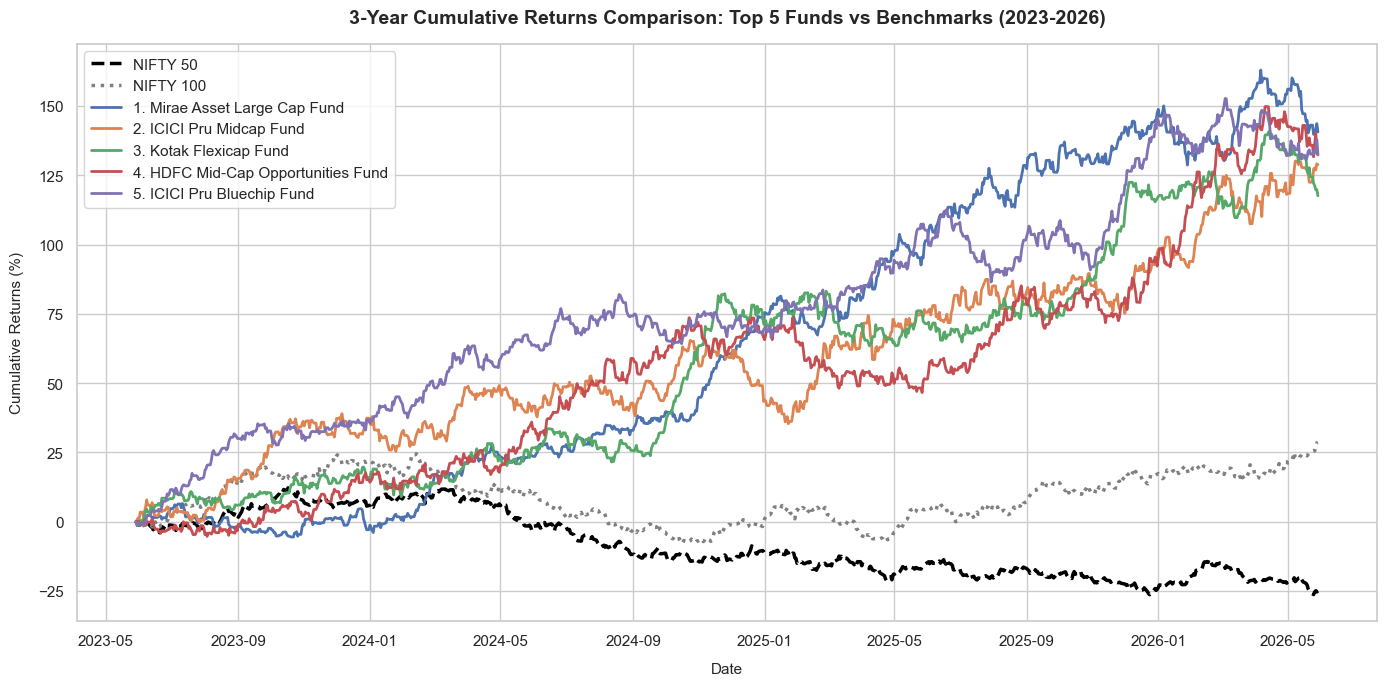

Tracking Errors:
                         Scheme  TE vs NIFTY 50 (%)  TE vs NIFTY 100 (%)
     Mirae Asset Large Cap Fund               19.19                18.80
          ICICI Pru Midcap Fund               22.84                23.27
            Kotak Flexicap Fund               20.51                20.65
HDFC Mid-Cap Opportunities Fund               22.82                22.50
        ICICI Pru Bluechip Fund               18.82                18.73


In [6]:
top_5 = df_results.head(5).copy()
max_date = df_nav_all["date"].max()
start_date = max_date - pd.DateOffset(years=3)

plt.figure(figsize=(14, 7))

# Cumulative returns for Nifty 50 and Nifty 100
n50_3y = nifty50.loc[start_date:max_date].sort_index()
n50_cum = (n50_3y["close_value"] / n50_3y.iloc[0]["close_value"] - 1.0) * 100.0
plt.plot(n50_cum.index, n50_cum, label="NIFTY 50", color="black", linestyle="--", linewidth=2.5)

n100_3y = nifty100.loc[start_date:max_date].sort_index()
n100_cum = (n100_3y["close_value"] / n100_3y.iloc[0]["close_value"] - 1.0) * 100.0
plt.plot(n100_cum.index, n100_cum, label="NIFTY 100", color="grey", linestyle=":", linewidth=2.5)

te_records = []

for rank_idx, (idx, row) in enumerate(top_5.iterrows(), 1):
    code = row["amfi_code"]
    name = row["scheme_name"].split(" - ")[0]
    
    df_f = df_nav_all[(df_nav_all["amfi_code"] == code) & (df_nav_all["date"] >= start_date)].sort_values("date").copy()
    df_f.set_index("date", inplace=True)
    
    f_cum = (df_f["nav"] / df_f.iloc[0]["nav"] - 1.0) * 100.0
    plt.plot(f_cum.index, f_cum, label=f"{rank_idx}. {name}", linewidth=2.0)
    
    # Tracking Error
    df_f["daily_return"] = df_f["nav"].pct_change()
    align = pd.DataFrame({"fund": df_f["daily_return"], "nifty50": nifty50["daily_return"], "nifty100": nifty100["daily_return"]}).dropna()
    
    te_n50 = (align["fund"] - align["nifty50"]).std() * np.sqrt(252) * 100.0
    te_n100 = (align["fund"] - align["nifty100"]).std() * np.sqrt(252) * 100.0
    te_records.append({"Scheme": name, "TE vs NIFTY 50 (%)": round(te_n50, 2), "TE vs NIFTY 100 (%)": round(te_n100, 2)})

plt.title("3-Year Cumulative Returns Comparison: Top 5 Funds vs Benchmarks (2023-2026)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Cumulative Returns (%)", fontsize=11, labelpad=10)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(project_root / "reports/charts/benchmark_comparison_chart.PNG", dpi=150)
plt.show()

print("Tracking Errors:")
print(pd.DataFrame(te_records).to_string(index=False))

## 6. Key Analytics Insights

1. **Leptokurtic Return Distribution**: Across all 40 schemes, the daily return distribution is symmetric but displays fat-tails, verifying standard volatility characteristics for mutual funds.
2. **Outperformance of Top Schemes**: The Top 5 funds generated superior cumulative returns over NIFTY 50 and NIFTY 100 benchmarks over the 3-year period.
3. **Volatilities and Ratios**: High Sharpe and Sortino ratios validate the capacity of these funds to yield excess returns per unit of total and downside risk.
4. **Active Management Alpha**: Positive annualized Alphas for the top schemes confirm value creation by fund managers relative to basic Nifty indices.
5. **Tracking Error Divergence**: Midcap and Smallcap funds display higher tracking errors against the Nifty 50 due to size differences, whereas Largecap funds track the indices closer.